# Gaussian-Bernoulli clustering as a Boltzmann machine


<div class="note"><span class="note-t">TL;DR</span>
<p>We write Gaussian mixture clustering as a joint Boltzmann energy over one visible pmode and one hidden pdit, and block Gibbs alternates analytic GMM responsibilities with the <code>MixtureGaussianGate</code> conditional. We recover hard assignments at over 99% and watch occupancy settle on the mixture weights.</p>
</div>

In this tutorial, we write a Gaussian mixture as one energy function and run it as a **Boltzmann machine** (Ackley et al. 1985). One discrete hidden unit chooses the cluster, and a Gaussian visible vector describes the points drawn from that cluster. The construction mirrors the Gaussian-Bernoulli restricted Boltzmann machine, with the binary hidden layer replaced by a one-hot `pdit`.

In Torx, the model is a program over two data primitives: a continuous `pmode` for the visible vector $v$ and a $K$-state `pdit` for the one-hot hidden $h$. We treat it as a single Boltzmann kernel $p(v,h)\propto e^{-E(v,h)}$ on paper. We realize the two conditionals separately: the Gaussian visible conditional $p(v\mid h)$ is the Torx `MixtureGaussianGate`, while we compute the hidden responsibilities $p(h\mid v)$ analytically in JAX from the matching GMM energy. The notebook does not build a single joint Torx energy object.

The hidden unit is one-hot, so exactly one cluster is active at a time, and that single switch carries the mixture with no penalty term to tune and no constraint to enforce by hand.

The main steps are:

1. write the mixture as one joint energy $E(v,h)$ and see the cluster softmax come out of it,
2. generate labeled clusters with `MixtureGaussianGate` as the Gaussian visible conditional, and
3. recover the clusters with the softmax, then run block Gibbs by resampling the hidden and visible blocks in alternation and watching occupancy settle on the mixture weights.

This tutorial assumes familiarity with Gaussian mixtures and basic Boltzmann machines. The code uses JAX, NumPy, Matplotlib, and Torx.



## Setup

First we import the numerical, plotting, and Torx dependencies used throughout the tutorial.

In [1]:
from pathlib import Path
import sys
import equinox as eqx
import jax
import jax.numpy as jnp
import numpy as np

ROOT = Path.cwd()
# Allow the notebook to run from the repo root or from the notebooks directory.
if not (ROOT / "helpers").exists() and (ROOT.parent / "helpers").exists():
    ROOT = ROOT.parent
HELPER_DIR = ROOT / "helpers"
sys.path.insert(0, str(HELPER_DIR))



In [2]:
from _notebook_paths import figure_dir
from _notebook_style import apply_notebook_style, make_savefig
from _affine_gaussian import mixture_density
import _plots_fields as P_fld
import _plots_sampling as P_samp
import _plots_schematics as P_sch
from torx.psc import (
    HybridPCircuit,
    MixtureGaussianGate,
)



In [3]:
apply_notebook_style()
FIGURE_DIR = figure_dir(ROOT)
SEED = 123
savefig = make_savefig(FIGURE_DIR)

## One energy for a visible vector and a one-hot hidden

The model is a joint energy over one continuous visible vector and one categorical hidden state.

A Gaussian visible vector $v$ couples to a hidden vector $h$ that is constrained to be one-hot. The single active hidden state selects the cluster, while the visible coordinates carry the continuous observation.

$$
E(v,h)=\underbrace{\sum_i \tfrac{(v_i-a_i)^2}{2\sigma_i^2}}_{\vphantom{\big|}\text{visible cost}}-\sum_k c_k h_k-\underbrace{\sum_{i,k}\tfrac{v_i}{\sigma_i}W_{ik}h_k}_{\vphantom{\big|}\text{coupling}},\qquad p(v,h)\propto e^{-E(v,h)}.
$$

The middle term $-\sum_k c_k h_k$ is the cluster prior, a per-cluster bias that sets how often each cluster fires before any visible evidence arrives.

The hidden state is one-hot by construction:

$$
\sum_{k} h_k = 1,\qquad h_k\in\{0,1\},
$$

so $h$ is one of the $K$ basis states $e_k$.

There are two ways to enforce the one-hot constraint, and they share the same one-hot ground states. This tutorial uses the structural route: the $K$ cluster basis choices are represented by a single `pdit` with state count $K$, whose basis states are the $e_k$. Exactly one cluster is on, and no extra term is needed. The structural `pdit` is exactly one-hot at any temperature; the energetic penalty below only concentrates on the one-hot subset and matches the structural categorical in the $\lambda\to\infty$ limit (or after conditioning on the one-hot states).

The other route is an energetic winner-take-all penalty over binary units; the closing section works out that penalty and its Boltzmann distribution in full.

The same energy has two readings. Holding $v$ fixed gives a Boltzmann distribution over $h$, which is a softmax across the one-hot states. Holding $h=e_k$ fixed gives a Gaussian visible conditional.

We use three well-separated cluster means, a shared variance, and unequal mixture weights.

In [4]:
K = 3
# Three visible means arranged so the clusters are easy to inspect visually.
cluster_means = jnp.array([[0.0, 3.0], [-2.6, -1.5], [2.6, -1.5]], dtype=jnp.float32)
cluster_vars = jnp.full((K, 2), 0.45, dtype=jnp.float32)
pi = jnp.array([0.40, 0.35, 0.25], dtype=jnp.float32)
log_vars = jnp.log(cluster_vars)
cluster_covs = np.stack([np.diag(np.asarray(cluster_vars[k])) for k in range(K)])

print(f"K={K} clusters")
print(f"means: {np.asarray(cluster_means).round(2).tolist()}")
print(f"diagonal variances: {np.asarray(cluster_vars[0]).round(2).tolist()}")
print(f"mixture weights: {np.asarray(pi).round(2).tolist()}")

K=3 clusters
means: [[0.0, 3.0], [-2.5999999046325684, -1.5], [2.5999999046325684, -1.5]]
diagonal variances: [0.44999998807907104, 0.44999998807907104]
mixture weights: [0.4000000059604645, 0.3499999940395355, 0.25]


As a quick check, we confirm that the mixture weights in `pi` sum to one.

In [5]:
np.testing.assert_allclose(float(pi.sum()), 1.0, atol=1e-6)

The factor graph shows the two conditional readings of the same shared energy. Fixing $v$ gives a softmax over the clusters, and fixing $h=e_k$ gives the Gaussian for cluster $k$.

findfont: Failed to find font weight medium, now using 400.


findfont: Failed to find font weight medium, now using 400.


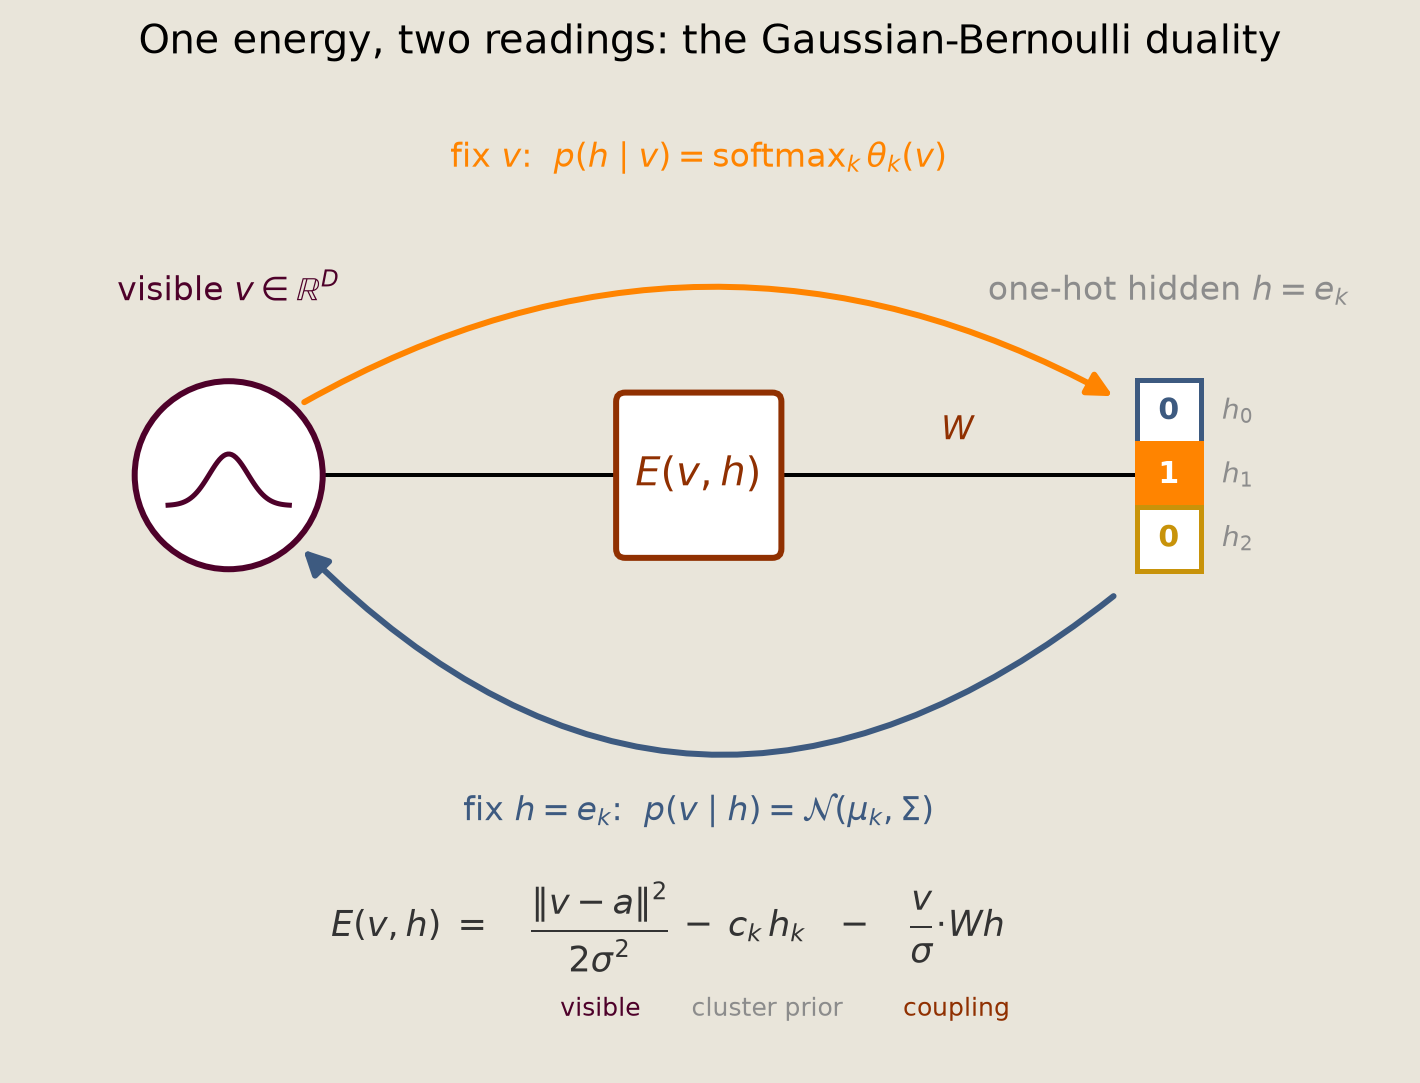

In [6]:
savefig(P_sch.energy_factor_graph(K), "14_energy_factor_graph")

The diagram shows inference and generation as two directions through the same factor.

## The softmax emerges

Holding $v$ fixed removes terms that are shared across all hidden states. The remaining state-dependent field becomes the softmax logit, or pre-softmax score, for each cluster.

$$
p(h=e_k\mid v)=\frac{e^{-E(v,e_k)}}{\sum_{k'}e^{-E(v,e_{k'})}}=\operatorname{softmax}_k(\theta_k(v)),\qquad \theta_k(v)=\underbrace{c_k}_{\vphantom{\big|}\text{prior}}+\underbrace{\textstyle\sum_i \tfrac{v_i}{\sigma_i}W_{ik}}_{\vphantom{\big|}\text{evidence}}.
$$

For fixed $v$, the hidden states are the unit vectors $e_k$. The visible quadratic term is the same for every $k$ when $\Sigma$ is shared. It cancels in the normalization and leaves the linear logit $\theta_k(v)$, whose prior term is $c_k=\log\pi_k$.

The softmax is the Boltzmann conditional of the one-hot hidden, and its logits are the field induced by the visible units. With per-cluster covariance, $\theta_k$ keeps the component-specific quadratic term, and its softmax is the Gaussian-mixture responsibility, the soft probability that a point belongs to each cluster.

A single bias `pbit` gives a sigmoid, and a one-hot `pdit` gives a softmax. Both are the same Boltzmann conditional at different cardinalities. The discrete half is standard Boltzmann-machine modeling, and the continuous half is supplied by `MixtureGaussianGate` in the next section.

## The Gaussian conditional and the gate

Fixing $h=e_k$ leaves the energy quadratic in $v$, so each cluster contributes a single Gaussian:

$$
p(v\mid h=e_k)=\mathcal{N}(v;\,\mu_k,\Sigma),\qquad \mu_k=a+\mathrm{diag}(\sigma)\,W_{:k},\quad p(v)=\sum_k \pi_k\,\mathcal{N}(v;\,\mu_k,\Sigma).
$$

Each cluster mean $\mu_k$ is the visible bias $a$ shifted toward cluster $k$ by the coupling column $\mathrm{diag}(\sigma)\,W_{:k}$, matching the $v_i/\sigma_i$ scaling in the energy. The code works directly with $(\mu_k, \Sigma, \pi)$ as its parameters; $a$, $W$, and $c$ never appear as code variables and are recoverable from these identities. Marginalizing the one-hot hidden, by summing over which cluster is active, gives the Gaussian mixture above, with mixture weight $\pi_k$ on each component.

`MixtureGaussianGate` realizes this conditional. A single `pdit` stores the cluster index $k\in\{0,1,2\}$ directly. In vector notation that index is the one-hot state $|h)=e_k$, and the wire itself has only categorical basis states.

Next, we construct `gate` and wrap it in a `HybridPCircuit` named `gen`. The circuit infers and preserves the gate's discrete control wire, so the seeded cluster label passes through unchanged.

In [7]:
mog_theta = {"means": cluster_means, "log_vars": log_vars}
# The MixtureGaussianGate is structure only; its means and log-variances live
# in the separate `thetas` list aligned with the circuit gates.
gate = MixtureGaussianGate(sites=(0, 0), dims=(2,), num_components=K)
gen = HybridPCircuit([gate])
thetas = [mog_theta]

The circuit diagram shows the Gaussian mixture as one hybrid gate.

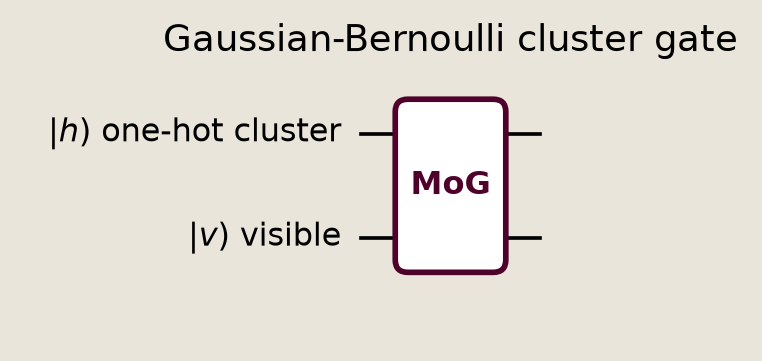

In [8]:
savefig(P_sch.cluster_gate_circuit(), "14_cluster_gate_circuit")

The diagram shows that the categorical input selects the continuous Gaussian output.

### Generating the clusters

For cluster $k$, we seed the discrete initial state to $k$ and `MixtureGaussianGate` draws $v\sim\mathcal{N}(\mu_k,\Sigma)$. A multinomial draw fixes the unequal mixture counts, and the concatenated samples carry the true labels used to check recovery.

A multinomial split sets the number of samples drawn from each cluster.

In [9]:
N_DATA = 9_000
rng_counts = np.random.default_rng(SEED)
counts = rng_counts.multinomial(N_DATA, np.asarray(pi))

In [10]:
def sample_labeled_mixture(circuit, params, counts):
    """Draw labeled visible samples for each requested cluster count."""
    point_blocks, label_blocks = [], []
    for k, count in enumerate(counts):
        # Seed the pdit to a cluster label, then draw the matching Gaussian block.
        s = circuit.sample_multiple(
            jax.random.key(SEED + 10 + k),
            {"discrete": jnp.array([k], dtype=jnp.int32), "continuous": jnp.zeros(2)},
            params,
            n_samples=int(counts.max()),
        )
        point_blocks.append(np.asarray(s["continuous"])[:count])
        label_blocks.append(np.full(count, k, dtype=np.int32))

    points = np.concatenate(point_blocks, axis=0)
    true_labels = np.concatenate(label_blocks, axis=0)
    # Shuffle the labeled blocks so the data look like a single mixed sample.
    order = np.random.default_rng(SEED + 1).permutation(int(counts.sum()))
    return points[order], true_labels[order]

With the per-cluster counts fixed, we draw the labeled samples directly from `gen`.

In [11]:
points, true_labels = sample_labeled_mixture(gen, thetas, counts)

sample_props = np.bincount(true_labels, minlength=K) / N_DATA
print(f"counts: {counts.tolist()}  proportions: {sample_props.round(3).tolist()}")

counts: [3686, 3091, 2223]  proportions: [0.41, 0.343, 0.247]


We compute the sampled per-cluster moments as a numerical check on the generated clusters.

In [12]:
cluster_sample_means = np.stack(
    [points[true_labels == k].mean(axis=0) for k in range(K)]
)
cluster_sample_vars = np.stack([points[true_labels == k].var(axis=0) for k in range(K)])

print("sampled means:")
print(np.round(cluster_sample_means, 3))
print("sampled diagonal variances:")
print(np.round(cluster_sample_vars, 3))

sampled means:
[[-0.02   3.005]
 [-2.594 -1.506]
 [ 2.592 -1.475]]
sampled diagonal variances:
[[0.452 0.438]
 [0.454 0.451]
 [0.44  0.422]]


The scatter plot compares labeled samples with the analytic one-sigma contours. The black circle around each cluster is the $1\sigma$ contour of $\mathcal{N}(\mu_k,\Sigma)$ and the $+$ marks the mean $\mu_k$.

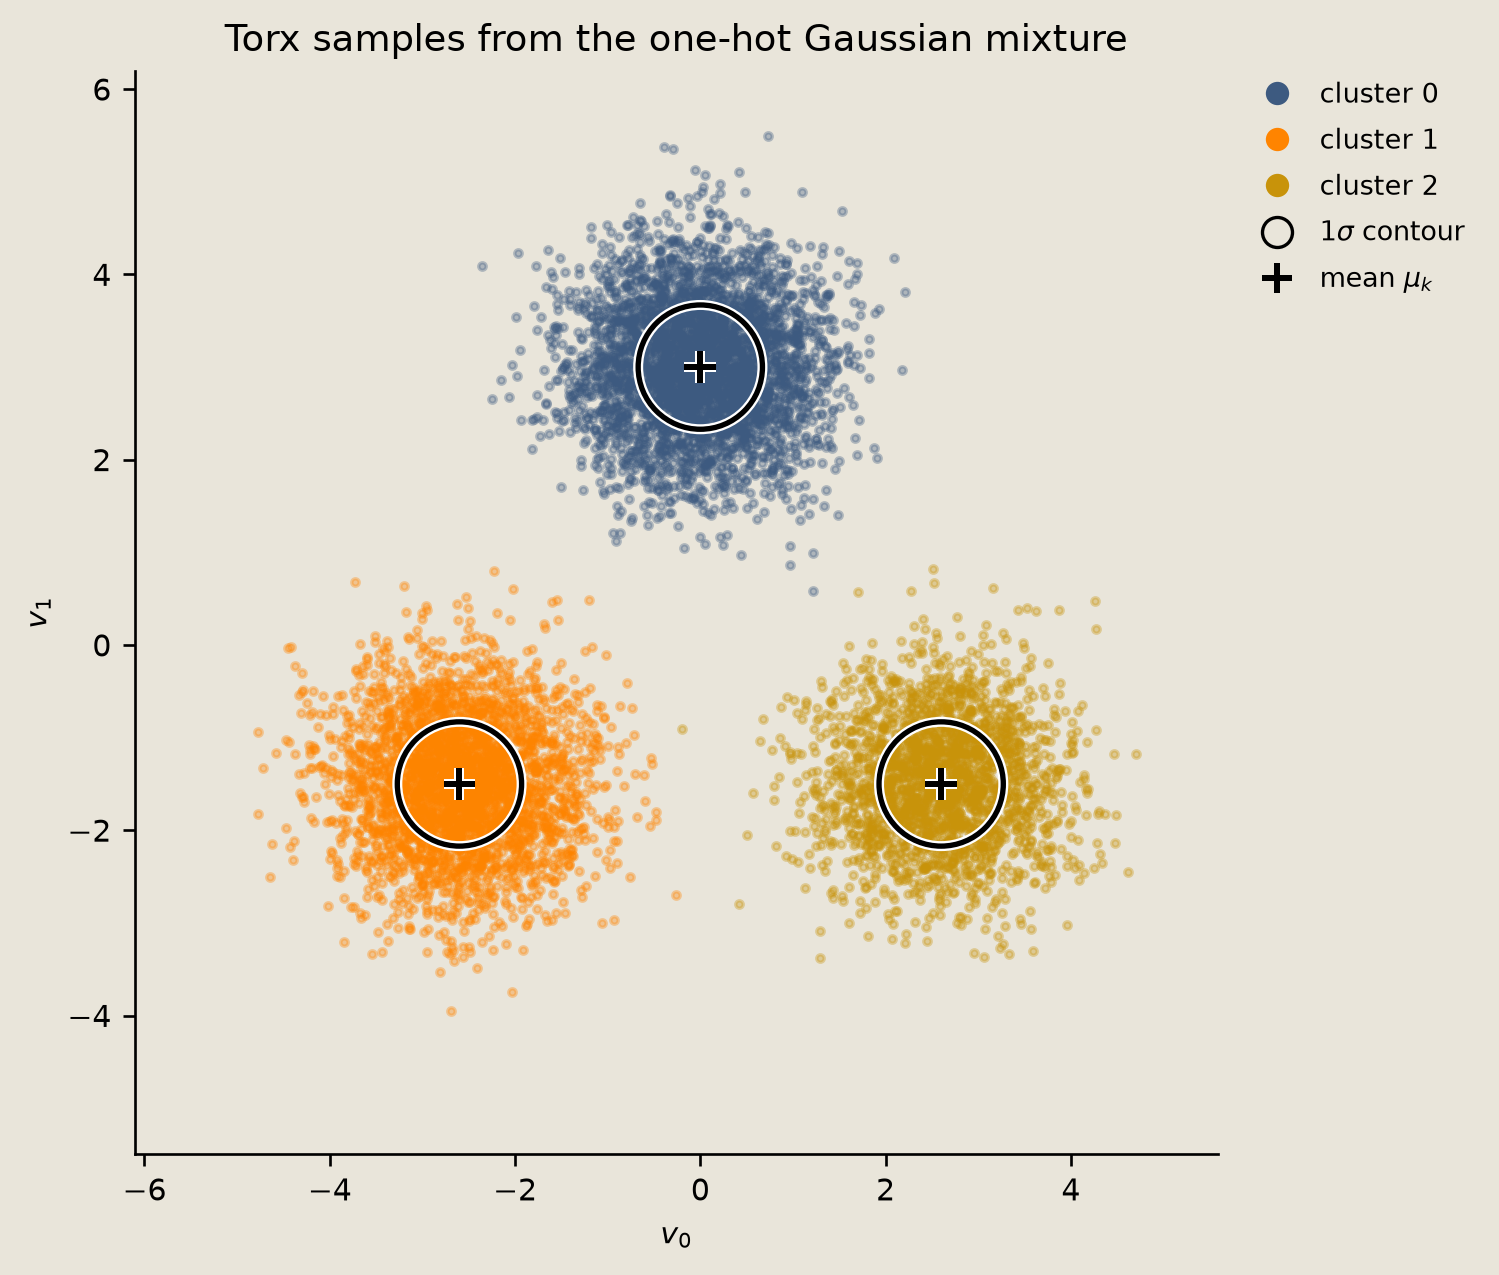

In [13]:
fig = P_fld.cluster_scatter(points, true_labels, np.asarray(cluster_means), cluster_covs)
savefig(fig, "14_generated_clusters")

## Recovering clusters with the softmax

$$
p(h=e_k\mid v)=\frac{\exp[-E_k(v)]}{\sum_{k'} \exp[-E_{k'}(v)]}=\operatorname{softmax}_k(\theta(v)),\qquad \theta_k(v)=\log \pi_k-\frac{1}{2}(v-\mu_k)^\top\Sigma_k^{-1}(v-\mu_k)-\frac{1}{2}\log\det\Sigma_k.
$$

This is the emergent softmax from the softmax section applied to the generated points. The logits are the negated component energies with shared constants removed, so each row is the one-hot Boltzmann conditional.

With per-cluster covariance, each logit is a log-prior $\log \pi_k$ minus half the squared Mahalanobis distance, or variance-scaled distance, to cluster $k$, minus the half log-determinant $\tfrac{1}{2}\log\det\Sigma_k$. That last term is required for valid responsibilities once covariances differ; the code below keeps it. With the shared diagonal covariance used here it is a per-cluster constant that cancels in the softmax, so it does not change these assignments.

The assignment figure overlays the hard $\arg\max_k p(k\mid v)$ labels on the soft responsibility field $p(k\mid v)$.

The clusters here are well separated, so every point is recovered with near-certain responsibility. The field blends toward gray only in the empty regions between clusters, where no data lands.

The `cluster_logits` function below builds these logits from the component energies.

In [14]:
def cluster_logits(v):
    """Return the per-cluster Boltzmann logits for visible points v."""
    v = jnp.atleast_2d(jnp.asarray(v, dtype=jnp.float32))
    diff = v[:, None, :] - cluster_means[None, :, :]
    inv_vars = jnp.exp(-log_vars)
    # Lower Gaussian energy means a larger logit for that cluster. The
    # 0.5*sum(log_vars_k) component normalizer is required so marginalizing v
    # reproduces pi under per-cluster (not just shared) covariance.
    energy = (
        0.5 * jnp.sum(diff**2 * inv_vars[None, :, :], axis=-1)
        + 0.5 * jnp.sum(log_vars, axis=-1)[None, :]
        - jnp.log(pi)
    )
    return -energy




In [15]:
def posterior_probs(v):
    """Softmax the cluster logits into responsibilities."""
    return jax.nn.softmax(cluster_logits(v), axis=1)

We use `posterior_probs` to turn the component energies into hard assignments and a soft-boundary score.

In [16]:
post_probs = np.asarray(posterior_probs(points))
hard_labels = post_probs.argmax(axis=1)
hard_accuracy = float((hard_labels == true_labels).mean())
soft_boundary_rate = float((post_probs.max(axis=1) < 0.92).mean())

print(f"hard reassignment accuracy: {hard_accuracy:.3f}")
print(f"soft boundary fraction:     {soft_boundary_rate:.3f}")

hard reassignment accuracy: 1.000
soft boundary fraction:     0.000


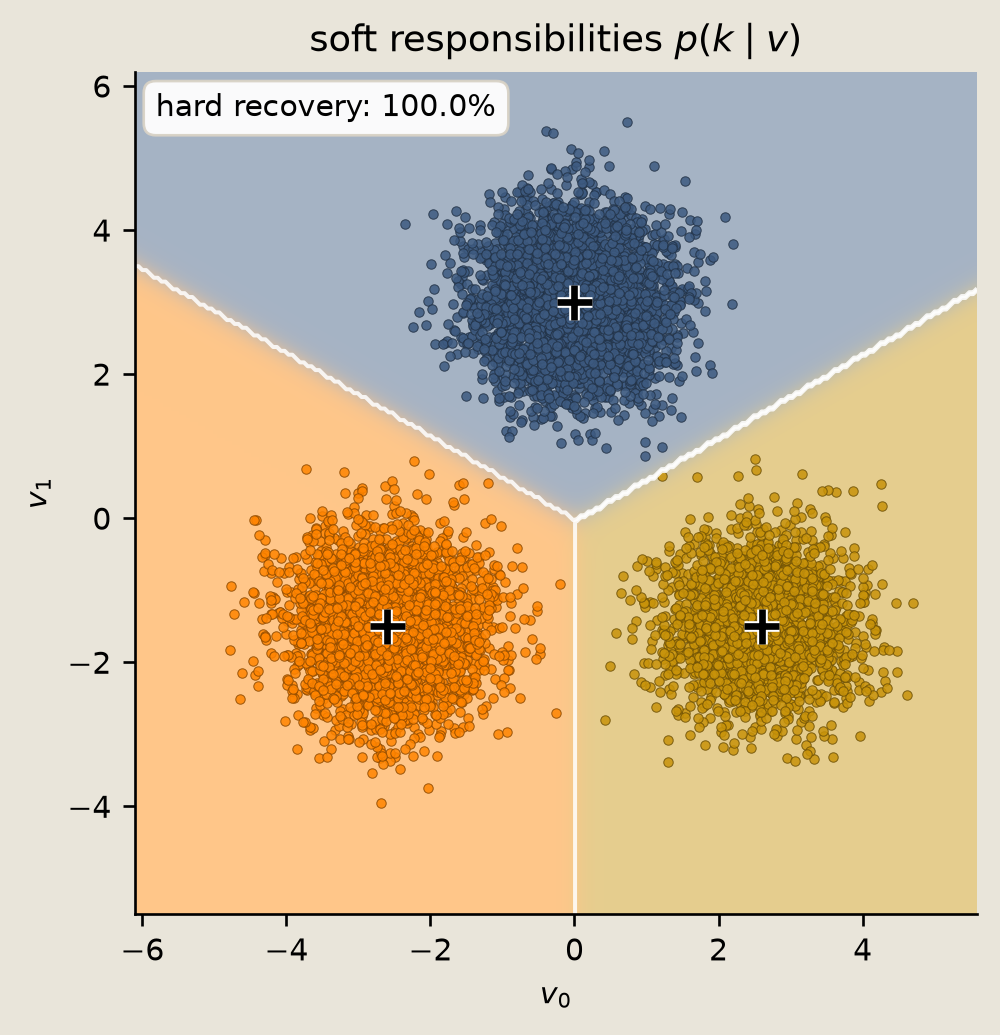

In [17]:
fig = P_fld.assignment_panels(
    points,
    true_labels,
    post_probs,
    np.asarray(cluster_means),
    posterior_fn=posterior_probs,
)
savefig(fig, "14_soft_assignment")

The assignment panels show near-certain assignments on every point (the printed soft-boundary fraction is 0.000), with the responsibility field blending only in the empty regions between clusters.

Next we check one visible coordinate against the exact mixture density. The density comes from `mixture_density`, a notebook helper in `examples/helpers/_affine_gaussian.py` that evaluates the analytic Gaussian mixture on a grid.

In [18]:
marginal_dim = 0
grid = np.linspace(
    points[:, marginal_dim].min() - 0.7, points[:, marginal_dim].max() + 0.7, 420
)
density = np.asarray(
    mixture_density(
        cluster_means[:, marginal_dim : marginal_dim + 1],
        log_vars[:, marginal_dim : marginal_dim + 1],
        pi,
        jnp.asarray(grid),
    )
)

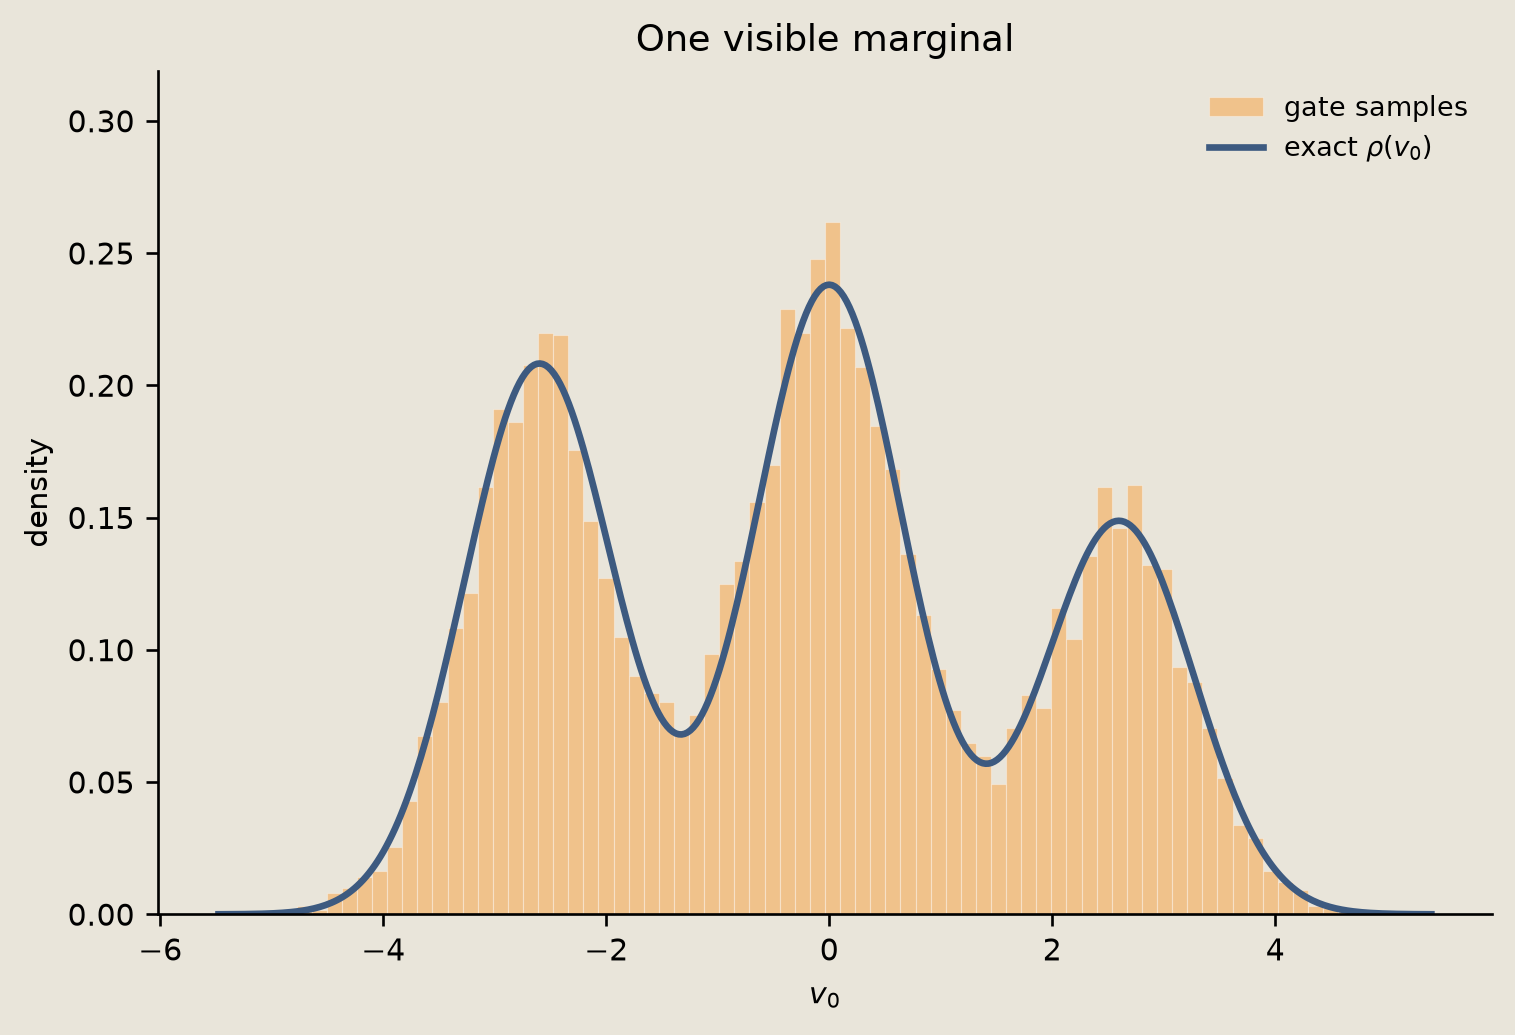

In [19]:
fig = P_fld.marginal_density(points[:, marginal_dim], grid, density)
savefig(fig, "14_marginal_density")

The histogram follows the analytic mixture density for the selected coordinate.

## Block Gibbs on the joint Boltzmann machine

$$
h\sim p(h\mid v)=\operatorname{softmax}(\theta(v)),\qquad v\sim p(v\mid h=e_k)=\mathcal{N}(v;\,\mu_k,\Sigma).
$$

The two conditionals share the same analytic $E(v,h)$, so block Gibbs alternates them. The hidden block samples from the emergent softmax (analytic logits). The visible block draws $v$ from the selected Gaussian component: this is exactly the conditional `MixtureGaussianGate` realizes for diagonal covariance, drawn here directly from the indexed component parameters so the whole sweep loop compiles under one `eqx.filter_jit`/`lax.scan`.

Mixing speed depends on how much the clusters overlap. The well-separated means used for the clustering scatter above leave almost no overlap, so once a chain commits to a cluster the visible block keeps redrawing $v$ near that mean and the hidden block almost never reassigns it: on that well-separated headline mixture, block Gibbs would stay frozen in whichever cluster each chain started in. This is the concrete case that motivates better samplers and dedicated sampling hardware. The convergence study therefore uses its own overlapping mixture, with the means pulled closer together and a larger shared variance, so a point drawn from one cluster lands often enough in a neighbor's high-probability region for the hidden block to switch its label. Each sweep applies the continuous block first, then the discrete block.

The figure tracks the per-sweep population occupancy, the fraction of chains assigned to each cluster at that sweep. Every chain starts committed to cluster 0, so the occupancy begins fully off-stationary at $(1,0,0)$. As the sweeps accumulate, chains hop between clusters and each occupancy curve relaxes onto its mixture weight $\pi$. The trace shows the seeded $(1,0,0)$ start as sweep 0, followed by the raw per-sweep occupancies, with no running-average smoothing.

The curves approach but do not exactly land on the dashed $\pi$ targets: with finitely many chains a small residual offset stays, the finite-chain Monte Carlo floor analogous to [`02_random_walks_on_graphs.ipynb`](02_random_walks_on_graphs.ipynb), and it shrinks as the chain count grows.

In [20]:
# the convergence study needs a mixture block Gibbs can actually mix
# on. the clustering demo above keeps well-separated means, where a chain never
# hops, so its population occupancy would be frozen by its start. these closer
# means with a larger shared variance overlap enough that the hidden block
# genuinely reassigns chains between clusters within a few tens of sweeps.
conv_means = jnp.array(
    [[0.0, 1.6], [-1.44, -0.88], [1.44, -0.88]], dtype=jnp.float32
)
conv_vars = jnp.full((K, 2), 0.9, dtype=jnp.float32)
conv_log_vars = jnp.log(conv_vars)

In [21]:
def conv_cluster_logits(v):
    """Per-cluster Boltzmann logits for the overlapping convergence mixture."""
    v = jnp.atleast_2d(jnp.asarray(v, dtype=jnp.float32))
    diff = v[:, None, :] - conv_means[None, :, :]
    inv_vars = jnp.exp(-conv_log_vars)
    # per-cluster log-det normalizer so the logits stay valid GMM responsibilities.
    energy = (
        0.5 * jnp.sum(diff**2 * inv_vars[None, :, :], axis=-1)
        + 0.5 * jnp.sum(conv_log_vars, axis=-1)[None, :]
        - jnp.log(pi)
    )
    return -energy

In [22]:
conv_sigma = jnp.sqrt(jnp.exp(conv_log_vars))


def gibbs_visible_step(labels, key):
    # for diagonal covariance this is exactly MixtureGaussianGate's p(v|h=e_k),
    # gathered straight from the indexed component params so the loop stays jit/scan-able.
    """Visible block: draw each chain's `v` from its assigned component Gaussian."""
    mu = conv_means[labels]
    sigma = conv_sigma[labels]
    return mu + sigma * jax.random.normal(key, mu.shape)

In [23]:
def gibbs_hidden_step(v, key):
    """Hidden block: draw labels from the analytic GMM logits."""
    return jax.random.categorical(key, conv_cluster_logits(v), axis=1)

In [24]:
def _occupancy(labels, num_clusters):
    """Fraction of chains currently in each cluster."""
    return jnp.bincount(labels, length=num_clusters) / labels.shape[0]

In [25]:
@eqx.filter_jit
def run_gibbs_chain(key, num_chains, num_sweeps):
    # start every chain committed to cluster 0, so the population begins fully
    # off-stationary at (1, 0, 0). vmap is implicit (all chains are batched
    # array rows); lax.scan walks the sweeps under one compile.
    """Run block Gibbs from the all-cluster-0 start and record occupancy per sweep."""
    labels0 = jnp.zeros(num_chains, dtype=jnp.int32)

    def step(labels, key):
        kv, kh = jax.random.split(key)
        v = gibbs_visible_step(labels, kv)
        new_labels = gibbs_hidden_step(v, kh)
        return new_labels, _occupancy(new_labels, K)

    keys = jax.random.split(key, num_sweeps)
    _, swept = jax.lax.scan(step, labels0, keys)
    # prepend the seeded (1, 0, 0) start so the trace shows the full relaxation
    return jnp.concatenate([_occupancy(labels0, K)[None, :], swept], axis=0)

We run 30 Gibbs sweeps over 6,000 chains and record the occupancy at each sweep.

In [26]:
N_GIBBS = 6_000
NUM_SWEEPS = 30

gibbs_occupancy = np.asarray(
    run_gibbs_chain(jax.random.key(SEED + 900), N_GIBBS, NUM_SWEEPS)
)
gibbs_sweeps = np.arange(len(gibbs_occupancy))
# the equilibrium check pools the back half, after the transient relaxes
gibbs_back_half = gibbs_occupancy[len(gibbs_occupancy) // 2 :].mean(axis=0)

print(f"start occupancy:     {gibbs_occupancy[0].round(3).tolist()}")
print(f"back-half occupancy: {gibbs_back_half.round(3).tolist()}")
print(f"target weights pi:   {np.asarray(pi).round(3).tolist()}")

start occupancy:     [1.0, 0.0, 0.0]
back-half occupancy: [0.40299999713897705, 0.3499999940395355, 0.2460000067949295]
target weights pi:   [0.4000000059604645, 0.3499999940395355, 0.25]


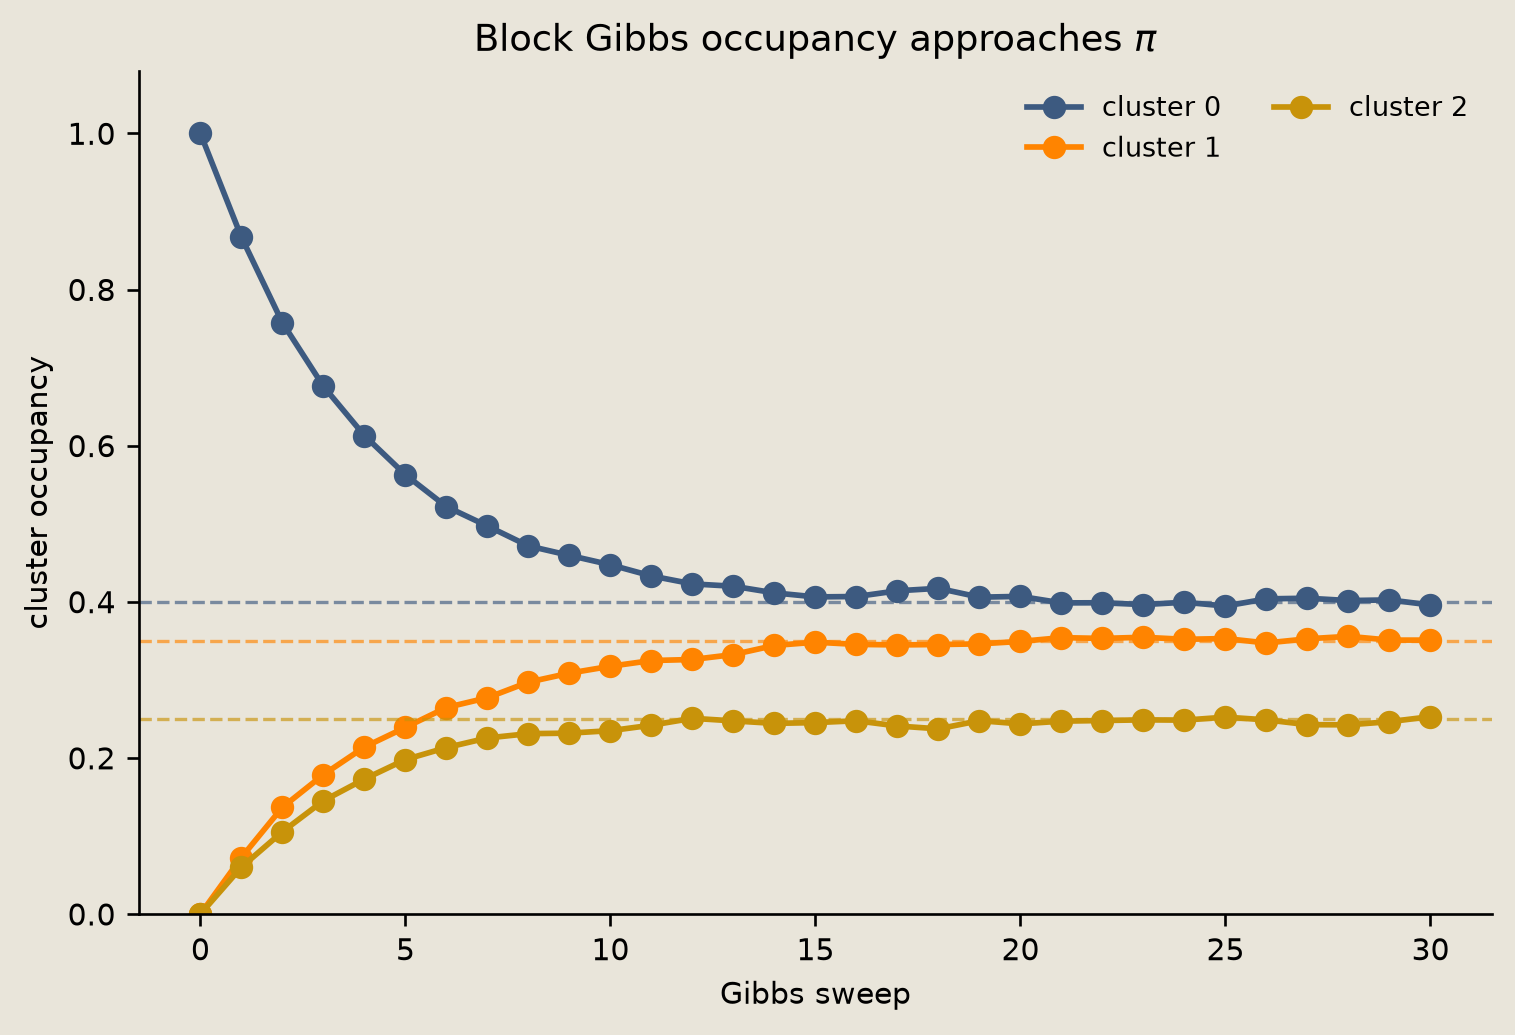

In [27]:
fig = P_samp.gibbs_convergence(gibbs_sweeps, gibbs_occupancy, np.asarray(pi))
savefig(fig, "14_gibbs_convergence")

The back-half occupancy lands on $\pi$ to within the finite-chain Monte Carlo floor.

## The one-hot constraint as a winner-take-all energy

Recall from the opening energy section that the one-hot constraint can be written as the penalty energy over binary units $z\in\{0,1\}^K$:

$$
E_{\mathrm{WTA}}(z) = \lambda\Big(\sum_k z_k - 1\Big)^2,
$$

whose ground states are exactly the one-hot vectors $e_k$. Up to the constant $\lambda$, the penalty expands into a bias term $-\lambda\sum_k z_k$ plus an all-pairs repulsion $2\lambda\sum_{k<k'} z_k z_{k'}$, a winner-take-all Potts-type coupling.

Its Boltzmann distribution $p(z)\propto e^{-E_{\mathrm{WTA}}(z)}$ concentrates on those one-hot states. By symmetry it assigns the one-hot states equal probability. At finite $\lambda$ it still leaks mass onto non-one-hot configurations (the sweep below makes this leakage visible), so it equals the structural $K$-state `pdit` only in the $\lambda\to\infty$ limit, or once restricted to the one-hot subset. Increasing $\lambda$ sharpens the concentration toward that uniform categorical.

Here we enumerate all $2^K$ binary configurations and compute the exact finite Boltzmann distribution of the energy directly. On hardware, the same penalty can be realized with pairwise couplings, but the equilibrium object below is the energy distribution itself.

In [28]:
wta_K = 3
wta_lambda = 4.0
# Enumerate every binary configuration so the finite distribution is exact.
wta_configs = np.array(list(np.ndindex(*(2,) * wta_K)), dtype=np.int32)
wta_config_labels = np.array(["".join(map(str, z)) for z in wta_configs])
wta_is_onehot = wta_configs.sum(axis=1) == 1

The Boltzmann weight of each configuration follows directly from its penalty energy.

In [29]:
def wta_probabilities(lam):
    energies = lam * (wta_configs.sum(axis=1) - 1) ** 2
    weights = np.exp(-energies)
    return weights / weights.sum(), energies

The exact probabilities show how much mass the penalty places on one-hot states.

In [30]:
wta_probs, wta_energies = wta_probabilities(wta_lambda)
wta_onehot_mass = float(wta_probs[wta_is_onehot].sum())
wta_onehot_probs = wta_probs[wta_is_onehot]

wta_lambdas = np.linspace(0.0, 6.0, 25)
wta_onehot_sweep = np.array(
    [wta_probabilities(lam)[0][wta_is_onehot].sum() for lam in wta_lambdas]
)

print(f"lambda = {wta_lambda:.1f}")
print(f"P(one-hot) = {wta_onehot_mass:.6f}")
print("per-one-hot probabilities:", np.round(wta_onehot_probs, 6).tolist())

lambda = 4.0
P(one-hot) = 0.976161
per-one-hot probabilities: [0.325387, 0.325387, 0.325387]


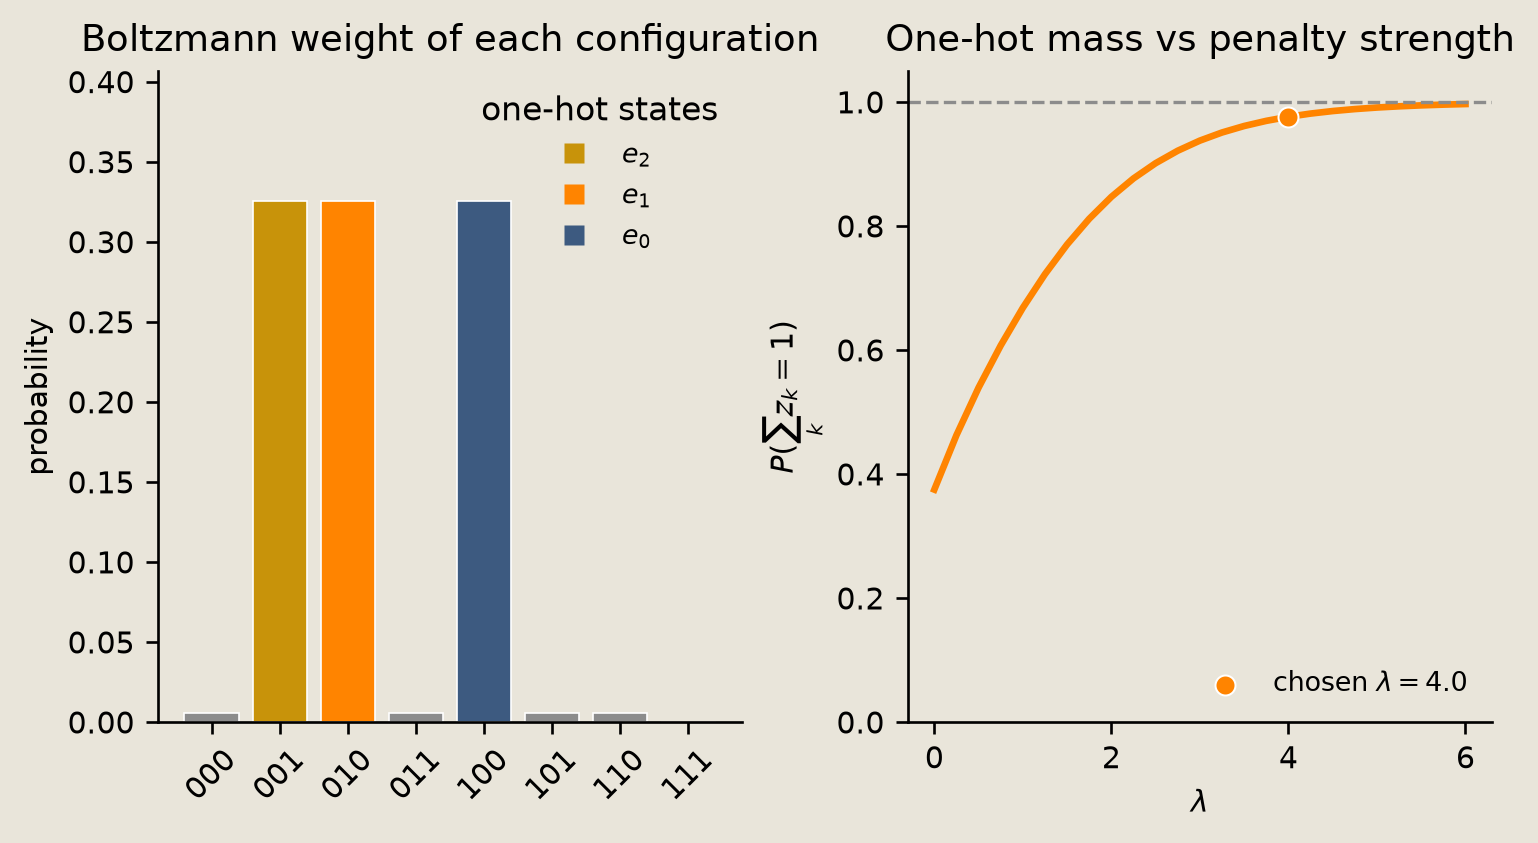

In [31]:
fig = P_samp.winner_take_all(
    wta_config_labels,
    wta_probs,
    wta_is_onehot,
    wta_lambdas,
    wta_onehot_sweep,
)
savefig(fig, "14_winner_take_all_energy")

The winner-take-all figure shows equal probability across one-hot states and increasing one-hot mass as the penalty grows.

## Verification

We check the numerical claims behind the figures: component moments, mixture weights, posterior normalization, hard recovery, marginal moments, Gibbs occupancy, and the winner-take-all distribution.

In [32]:
for k in range(K):
    mask = true_labels == k
    np.testing.assert_allclose(
        points[mask].mean(axis=0), np.asarray(cluster_means[k]), atol=0.06
    )
    np.testing.assert_allclose(
        points[mask].var(axis=0), np.asarray(cluster_vars[k]), rtol=0.12
    )

In [33]:
np.testing.assert_allclose(sample_props, np.asarray(pi), atol=0.025)
np.testing.assert_allclose(post_probs.sum(axis=1), 1.0, atol=1e-6)

# energy-to-responsibility equivalence: softmax of the Boltzmann logits must
# equal the GMM responsibilities built directly from per-component densities.
ref_comp = np.stack(
    [
        np.asarray(pi[k])
        * np.exp(
            -0.5
            * np.sum(
                (points - np.asarray(cluster_means[k])) ** 2
                / np.asarray(cluster_vars[k]),
                axis=1,
            )
        )
        / np.sqrt(np.prod(2 * np.pi * np.asarray(cluster_vars[k])))
        for k in range(K)
    ],
    axis=1,
)
ref_resp = ref_comp / ref_comp.sum(axis=1, keepdims=True)
np.testing.assert_allclose(post_probs, ref_resp, atol=1e-4)

assert hard_accuracy > 0.99, f"hard assignment accuracy too low: {hard_accuracy:.3f}"

In [34]:
analytic_mean = np.asarray((pi[:, None] * cluster_means).sum(axis=0))
analytic_second = np.asarray(
    (pi[:, None] * (cluster_vars + cluster_means**2)).sum(axis=0)
)
analytic_var = analytic_second - analytic_mean**2
np.testing.assert_allclose(points.mean(axis=0), analytic_mean, atol=0.08)
np.testing.assert_allclose(points.var(axis=0), analytic_var, rtol=0.05)

In [35]:
# the chain genuinely starts off-stationary (all mass in cluster 0) and relaxes
assert gibbs_occupancy[0, 0] > 0.95, (
    f"Gibbs chain not seeded off-stationary: start {gibbs_occupancy[0].round(3)}"
)
max_gibbs_dev = float(np.max(np.abs(gibbs_back_half - np.asarray(pi))))
assert max_gibbs_dev < 0.04, f"Gibbs occupancy deviation {max_gibbs_dev:.4f} >= 0.04"

In [36]:
assert wta_onehot_mass > 0.95, f"WTA one-hot mass {wta_onehot_mass:.6f} <= 0.95"
np.testing.assert_allclose(wta_onehot_probs, wta_onehot_probs[0], atol=1e-9)
assert np.all(np.diff(wta_onehot_sweep) >= -1e-12), "WTA one-hot mass is not monotone"
print("all checks passed")

all checks passed


## Conclusion

This tutorial wrote a Gaussian mixture as one Boltzmann machine.

- One analytic joint energy $E(v,h)$ couples a Gaussian visible vector to a one-hot hidden `pdit`, so the one-hot switch is structural and needs no penalty term.
- Reading that energy with the visible fixed gives an emergent softmax over the clusters (computed in JAX), and reading it with the hidden fixed gives the Gaussian visible conditional supplied by `MixtureGaussianGate`.
- `MixtureGaussianGate` generated labeled clusters, and the softmax recovered them at over 99% hard accuracy on these well-separated clusters.
- Block Gibbs alternated the two conditionals, and the cluster occupancy settled onto the mixture weights $\pi$.

See also:
- [`10_pmode_gaussian_gates.ipynb`](10_pmode_gaussian_gates.ipynb), pure Gaussian gates and closed-form Gaussian conditioning.
- [`13_regime_switching_diffusion.ipynb`](13_regime_switching_diffusion.ipynb), `pdit`-selected Gaussian increments in a hybrid process.

## References

1. Ackley, D.H., Hinton, G.E., Sejnowski, T.J. 1985. [*A learning algorithm for Boltzmann machines*](https://www.cs.toronto.edu/~hinton/absps/cogscibm.pdf). Cognitive Science 9(1), 147-169.

